# Exploratory Data Analysis (EDA) on Life Insurance Death Claims Dataset

This notebook performs a comprehensive EDA on the `li_death_claims.csv` dataset, which contains life insurance death claims data. We'll cover data loading, cleaning, univariate analysis, outlier detection, correlation analysis, business visualizations, feature engineering, skewness analysis, and output saving.

## 1. Libraries
We will use pandas for data manipulation, numpy for numerical operations, and matplotlib for plotting.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Data Loading
Load the dataset and display basic information.

In [2]:
# Load the dataset
df = pd.read_csv('../data/li_death_claims.csv')

# Display dataset info
print("Dataset Info:")
df.info()

print("\nFirst 5 rows:")
df.head()

print("\nDescriptive Statistics:")
df.describe(include='all')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   life_insurer                          150 non-null    object 
 1   year                                  149 non-null    object 
 2   claims_pending_start_no               149 non-null    float64
 3   claims_pending_start_amt              149 non-null    float64
 4   claims_intimated_no                   149 non-null    float64
 5   claims_intimated_amt                  149 non-null    float64
 6   total_claims_no                       149 non-null    float64
 7   total_claims_amt                      149 non-null    float64
 8   claims_paid_no                        149 non-null    float64
 9   claims_paid_amt                       149 non-null    float64
 10  claims_repudiated_no                  149 non-null    float64
 11  claim

,life_insurer,year,claims_pending_start_no,claims_pending_start_amt,claims_intimated_no,claims_intimated_amt,total_claims_no,total_claims_amt,claims_paid_no,claims_paid_amt,...,claims_unclaimed_amt,claims_pending_end_no,claims_pending_end_amt,claims_paid_ratio_no,claims_paid_ratio_amt,claims_repudiated_rejected_ratio_no,claims_repudiated_rejected_ratio_amt,claims_pending_ratio_no,claims_pending_ratio_amt,category
count,150,149,149.000000,149.000000,1.490000e+02,149.000000,1.490000e+02,149.000000,1.490000e+02,149.000000,...,149.000000,149.000000,1.490000e+02,149.000000,149.000000,149.000000,149.000000,149.000000,1.490000e+02,149
unique,46,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,Aegon,2020-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Individual Death Claims
freq,5,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,149
mean,NaN,NaN,279.221477,32.818025,8.488823e+04,2290.488723,8.516744e+04,2323.304603,8.341268e+04,2174.945713,...,24.224030,233.704698,3.823940e+01,0.941469,0.889200,0.027342,0.064307,0.003323,1.756590e-02,NaN
std,NaN,NaN,998.042360,93.182504,2.689849e+05,6511.165584,2.697987e+05,6600.625780,2.649624e+05,6242.151401,...,83.044402,846.982988,1.088848e+02,0.159193,0.157190,0.026001,0.048058,0.004775,2.267348e-02,NaN
min,NaN,NaN,0.000000,0.000000,1.890000e+02,5.406160,1.890000e+02,5.884616,1.800000e+02,5.171925,...,-0.003629,0.000000,-6.483702e-14,0.000000,0.000000,0.000000,0.000000,0.000000,-6.025839e-16,NaN
25%,NaN,NaN,2.000000,0.330000,1.243000e+03,77.410000,1.248000e+03,78.952235,1.202000e+03,70.170688,...,0.000000,2.000000,2.980006e-01,0.959633,0.890810,0.012365,0.032913,0.000248,2.560299e-03,NaN
50%,NaN,NaN,8.000000,2.000000,3.681000e+03,188.790000,3.686000e+03,192.868329,3.506000e+03,170.430141,...,0.000000,7.000000,1.545934e+00,0.972770,0.924742,0.020000,0.057702,0.001699,9.765686e-03,NaN
75%,NaN,NaN,39.000000,9.048578,1.372600e+04,692.260000,1.373000e+04,702.451208,1.317600e+04,650.328856,...,1.921269,25.000000,7.823212e+00,0.983852,0.950544,0.033473,0.081819,0.004014,2.341185e-02,NaN


## 3. Data Cleaning
Identify missing values, handle them, convert year to categorical, and fix floating-point issues.

In [3]:
# Identify missing values
print("Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values)

# Handle missing values: impute numeric with median, drop categorical missing
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f"Imputed missing values in {col} with median.")

categorical_cols = df.select_dtypes(include=['object']).columns
df = df.dropna(subset=categorical_cols)
print("Dropped rows with missing categorical values.")

# Convert year to categorical
if 'year' in df.columns:
    df['year'] = df['year'].astype('category')
    print("Converted 'year' column to categorical.")

# Handle negative near-zero floating point errors
float_cols = df.select_dtypes(include=[np.float64]).columns
for col in float_cols:
    df[col] = df[col].clip(lower=0)
    print(f"Clipped negative values in {col} to 0.")

print("Data cleaning completed.")

Missing values per column:
life_insurer                            1
year                                    2
claims_pending_start_no                 2
claims_pending_start_amt                2
claims_intimated_no                     2
claims_intimated_amt                    2
total_claims_no                         2
total_claims_amt                        2
claims_paid_no                          2
claims_paid_amt                         2
claims_repudiated_no                    2
claims_repudiated_amt                   2
claims_rejected_no                      2
claims_rejected_amt                     2
claims_unclaimed_no                     2
claims_unclaimed_amt                    2
claims_pending_end_no                   2
claims_pending_end_amt                  2
claims_paid_ratio_no                    2
claims_paid_ratio_amt                   2
claims_repudiated_rejected_ratio_no     2
claims_repudiated_rejected_ratio_amt    2
claims_pending_ratio_no                 2
claims_

## 4. Univariate Analysis
Generate histograms for all numerical columns.

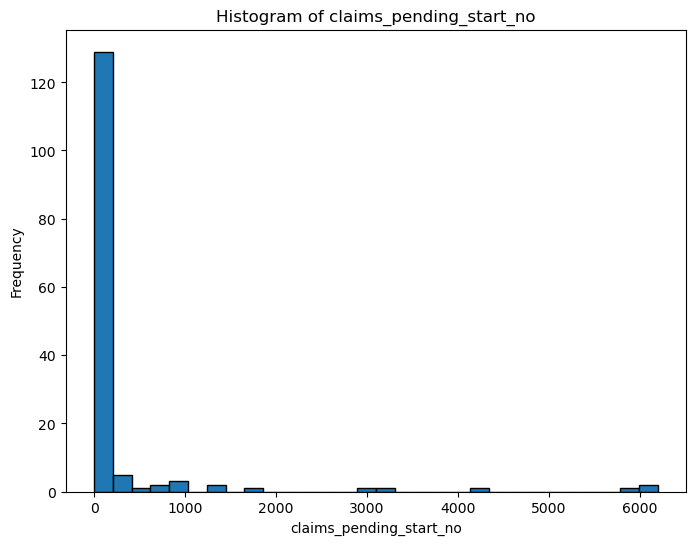

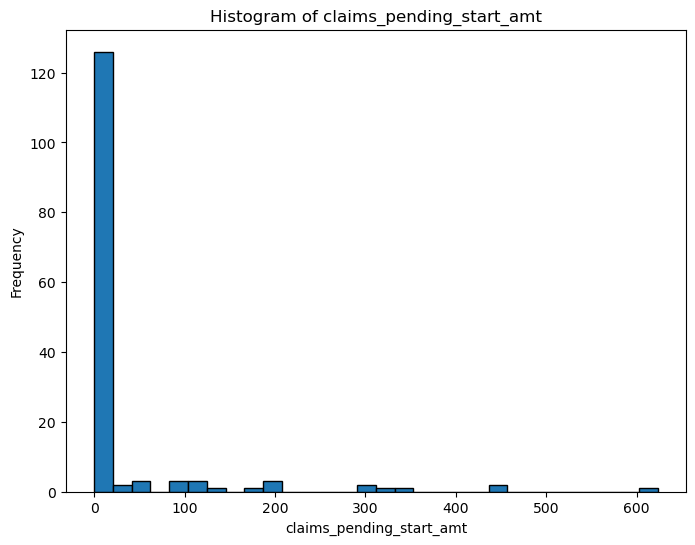

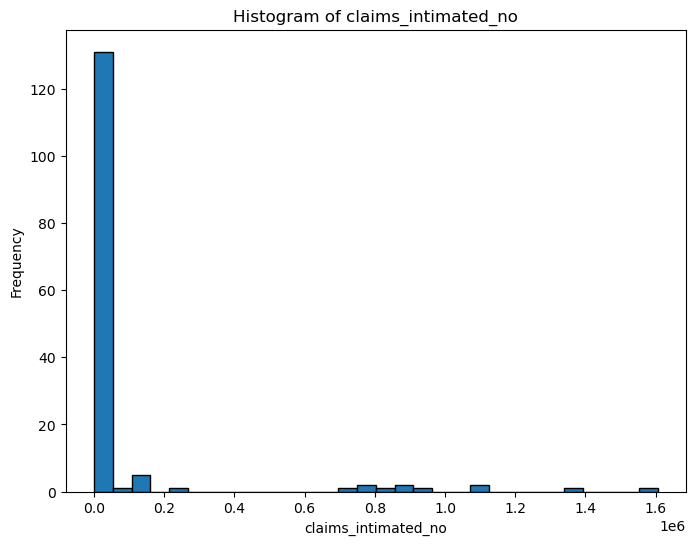

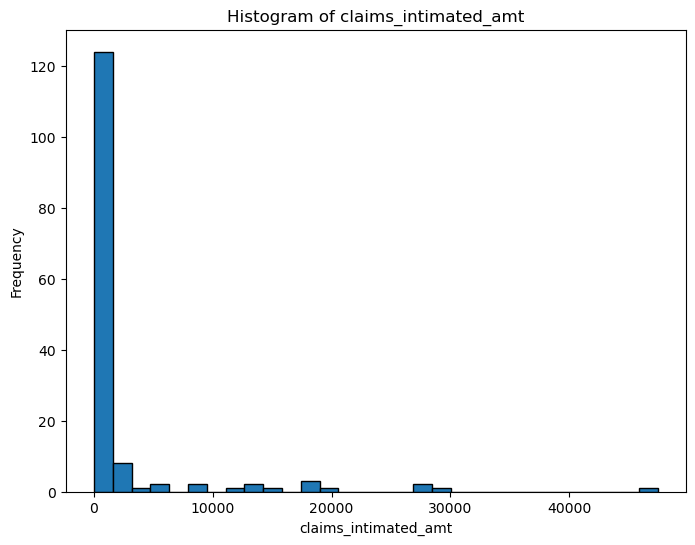

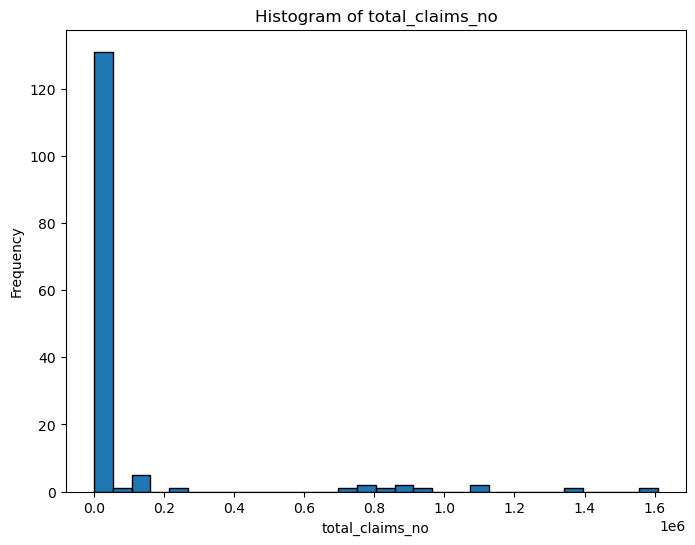

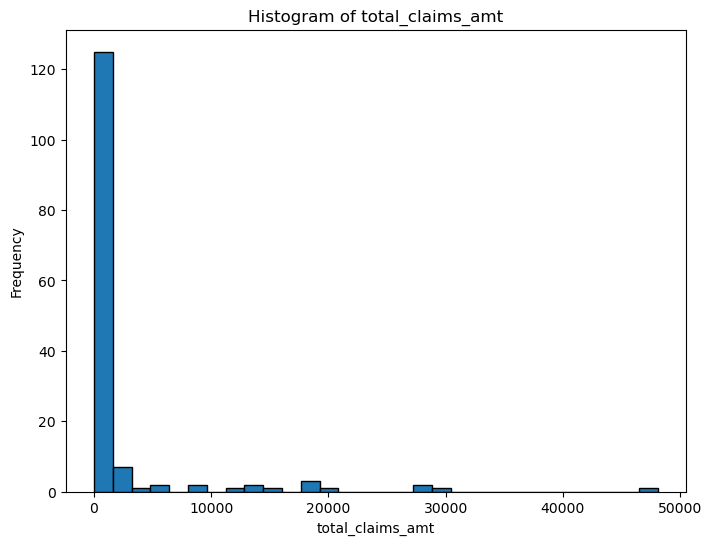

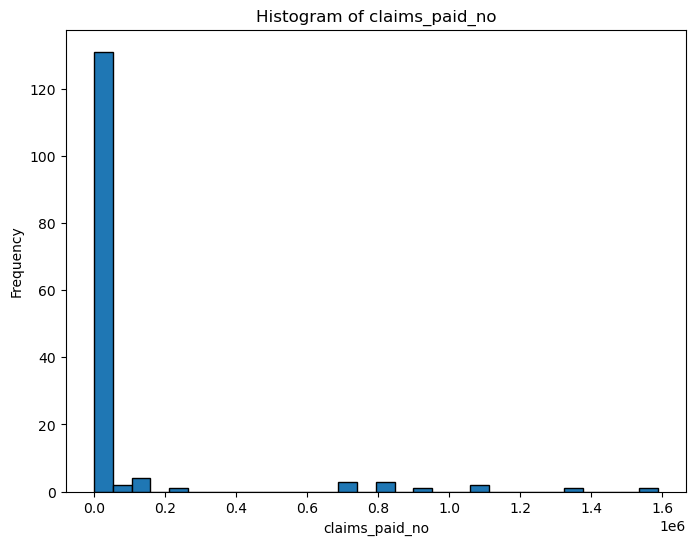

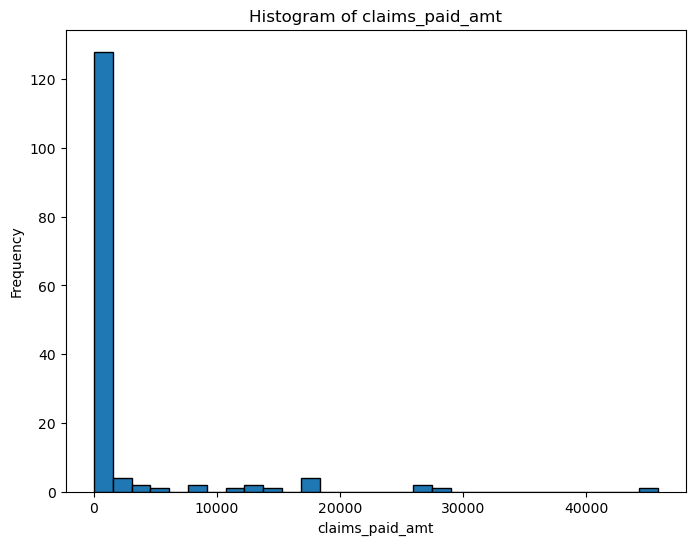

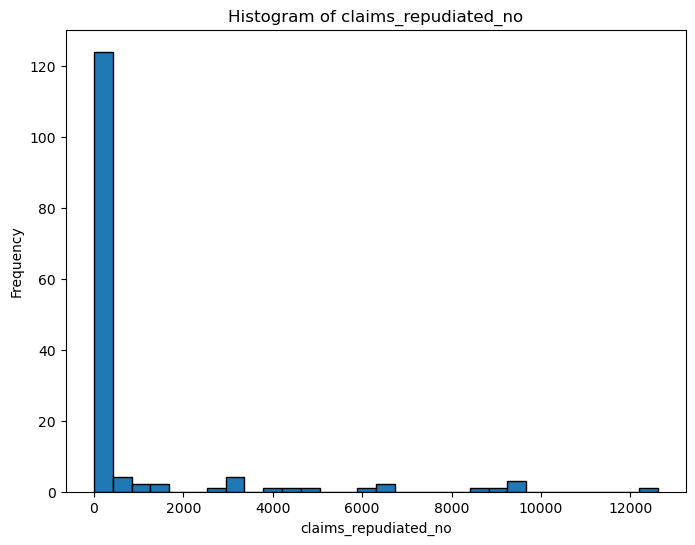

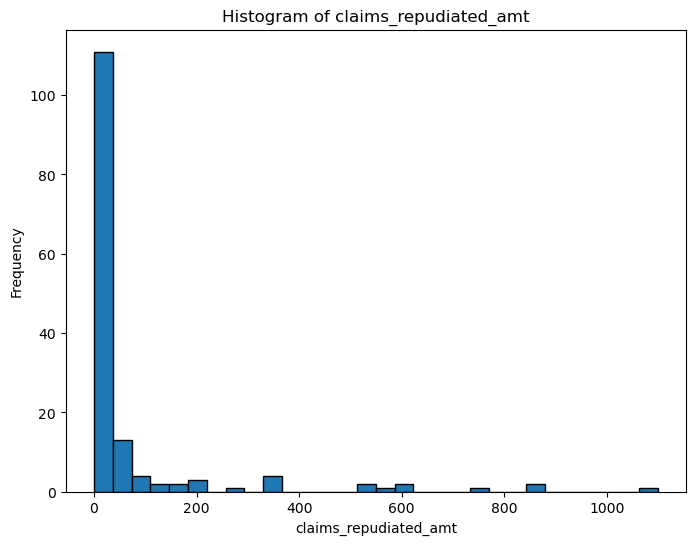

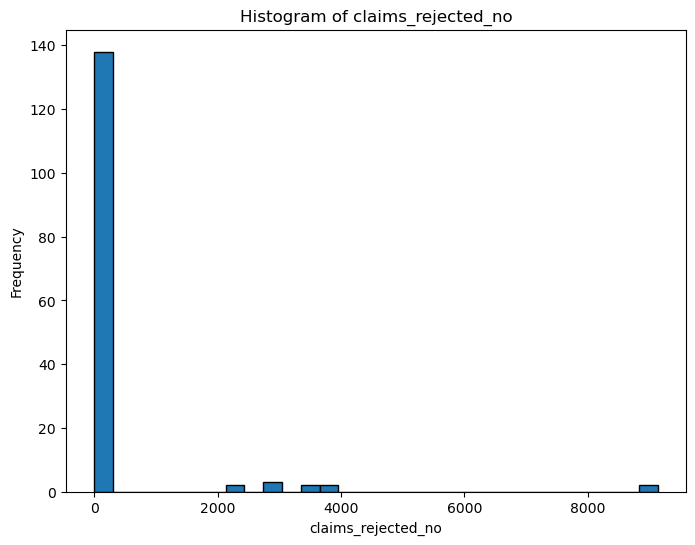

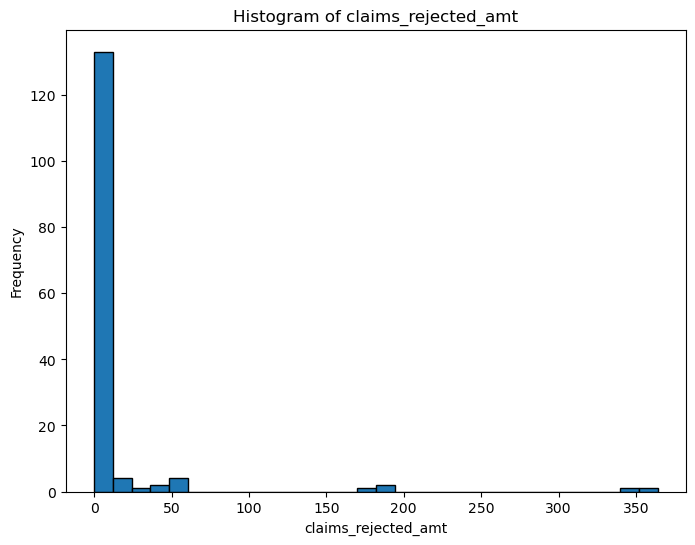

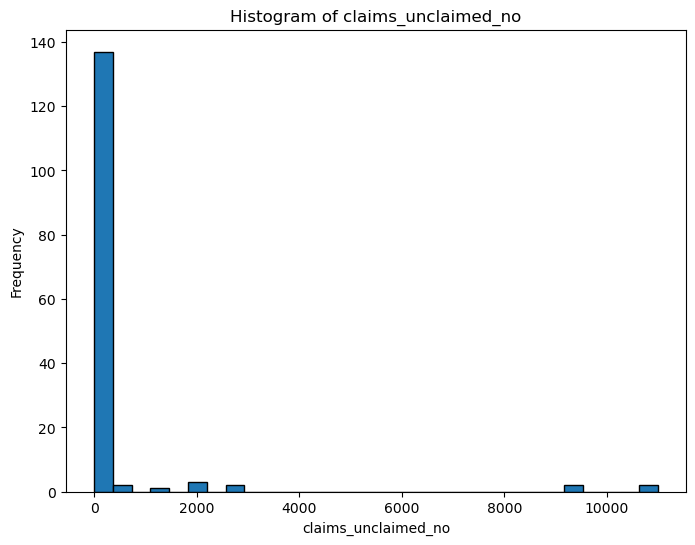

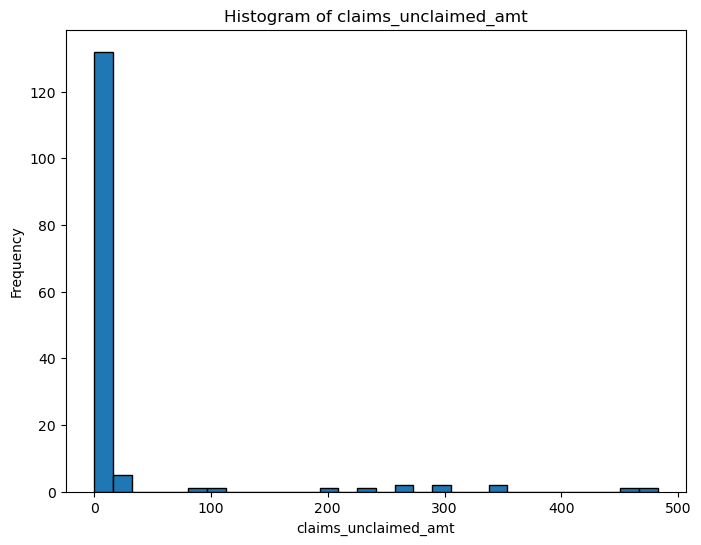

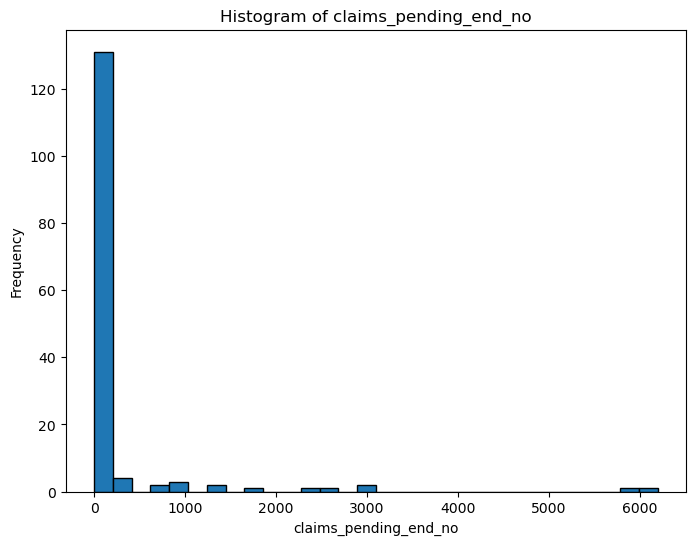

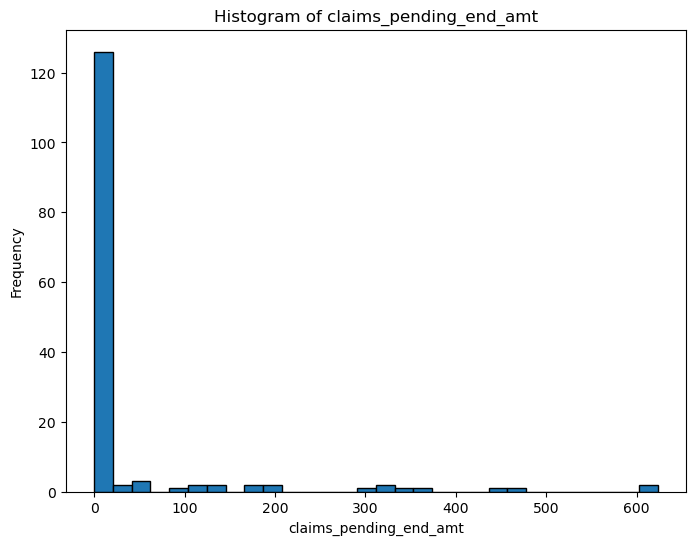

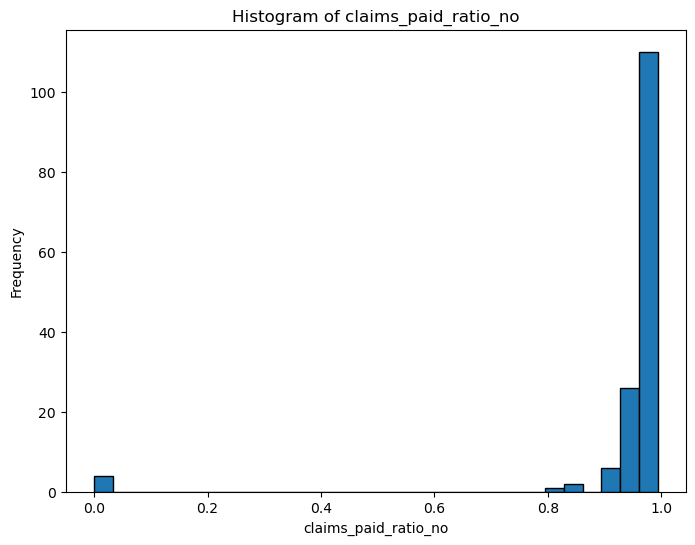

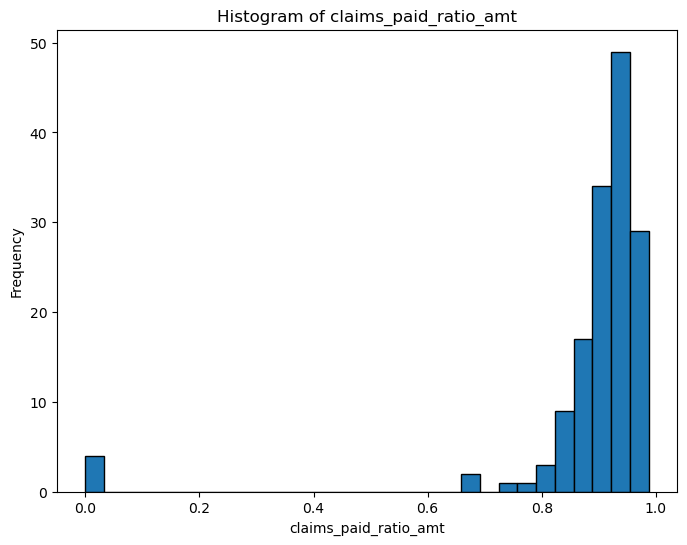

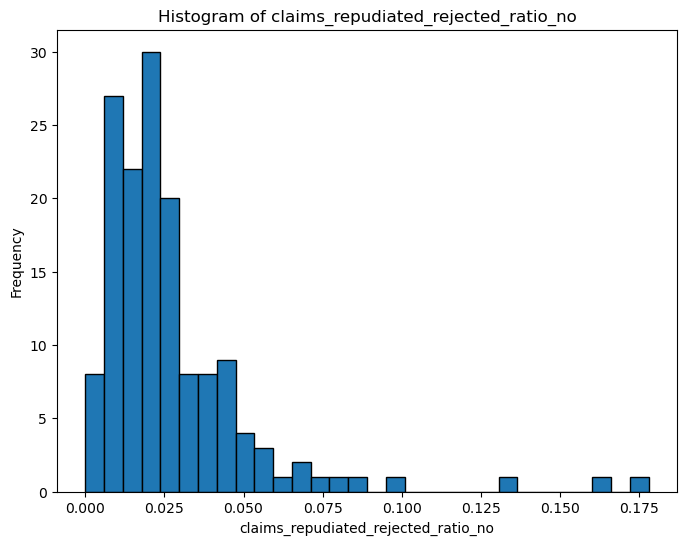

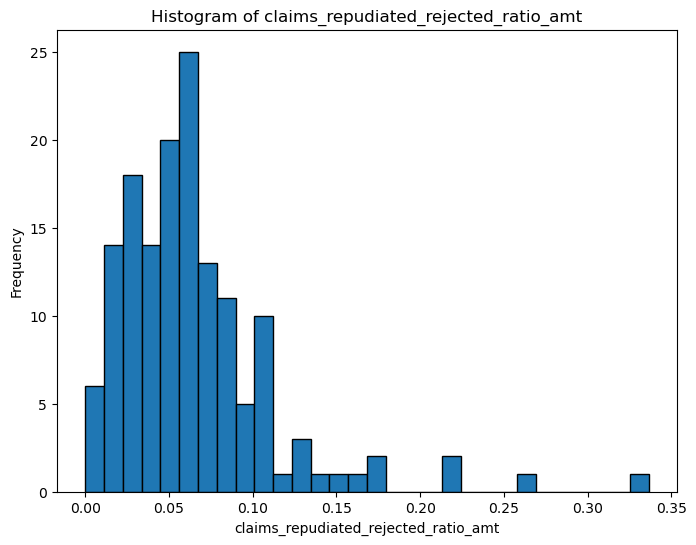

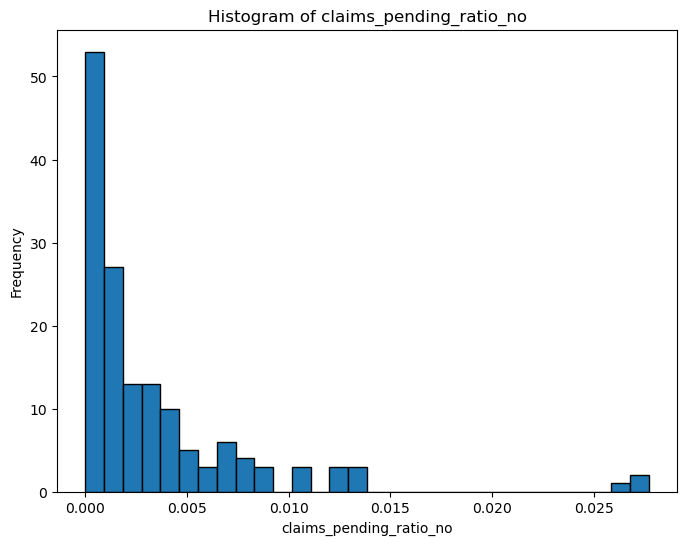

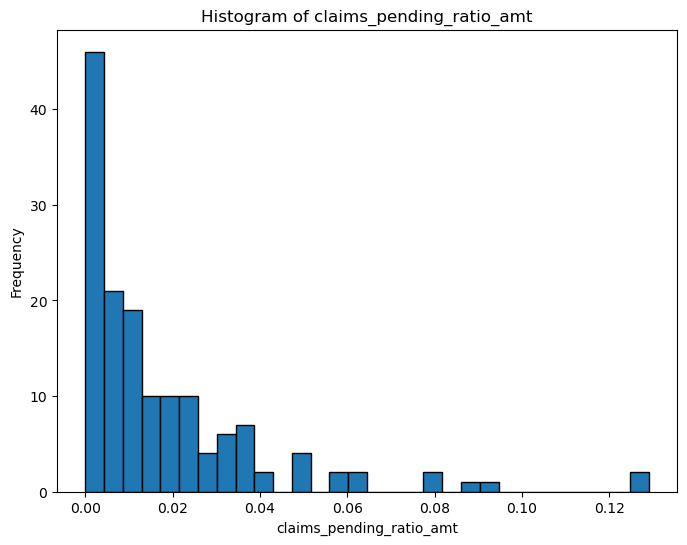

In [4]:
# Get numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Generate histograms
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    plt.hist(df[col], bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## 5. Outlier Detection
Create boxplots for all numerical columns.

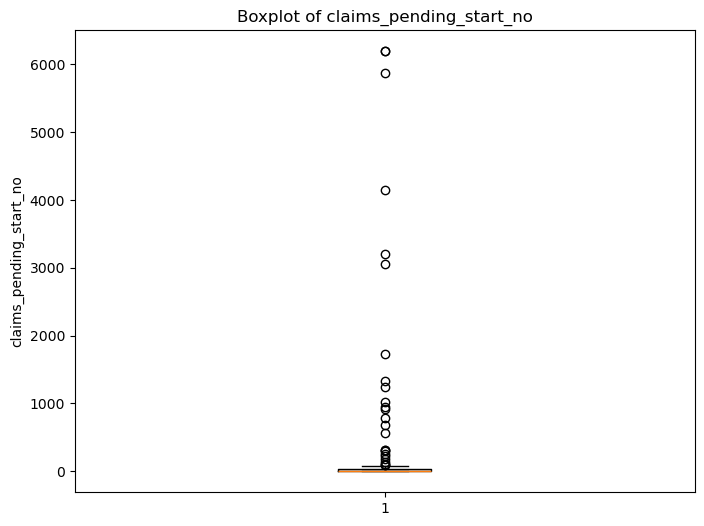

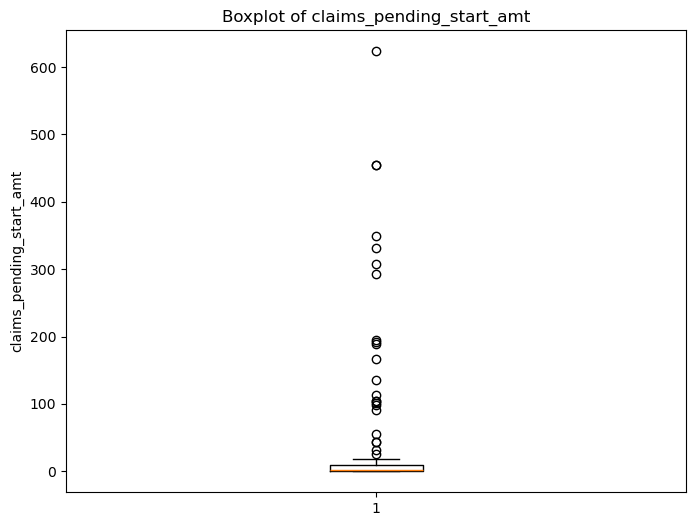

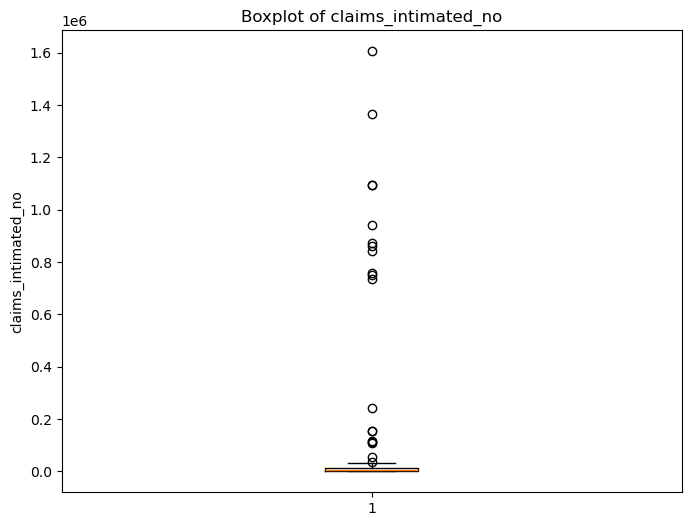

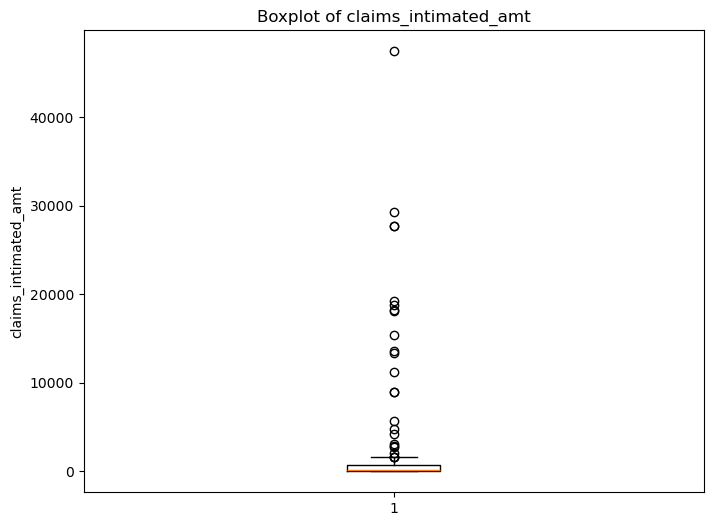

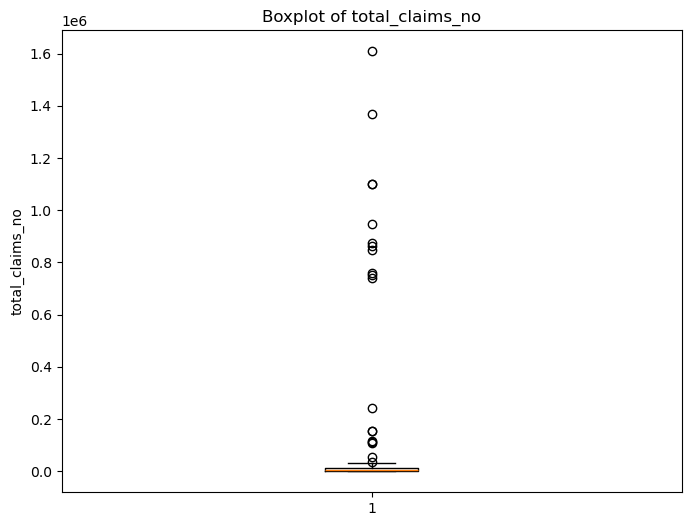

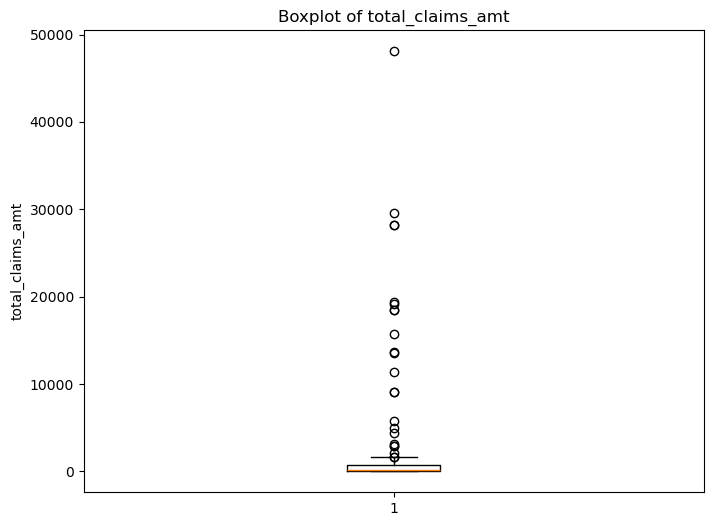

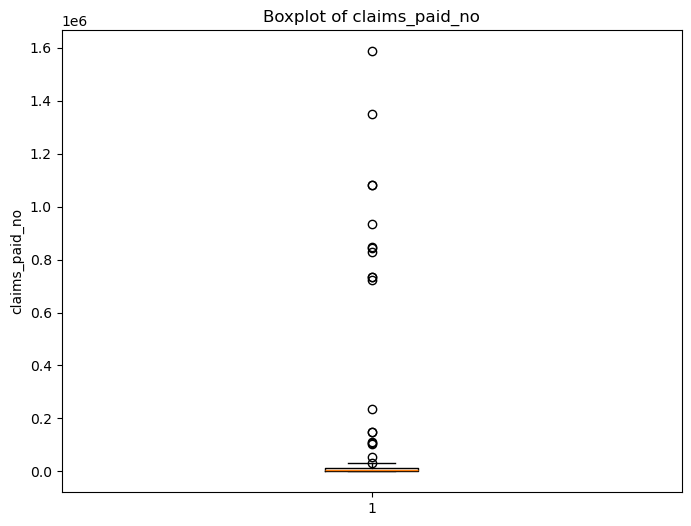

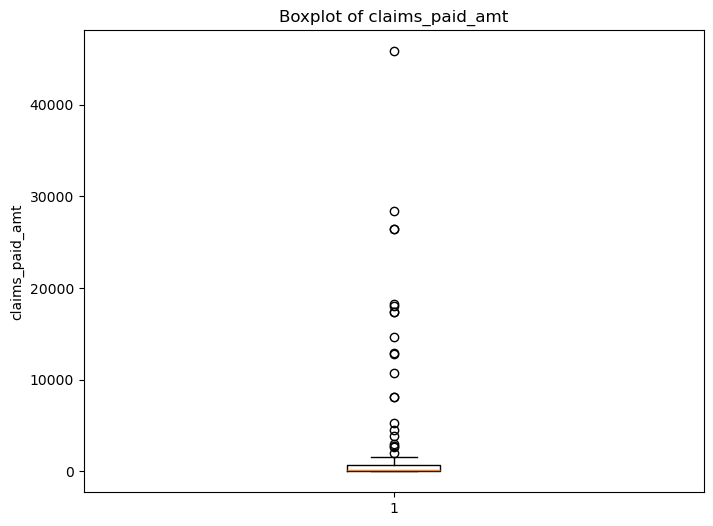

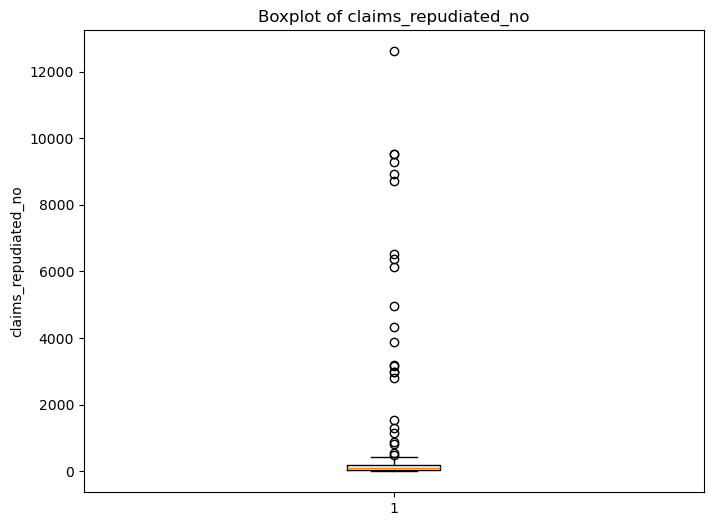

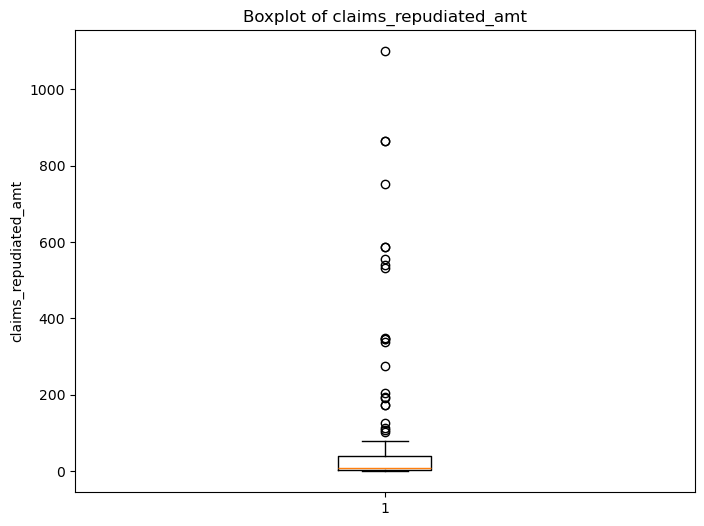

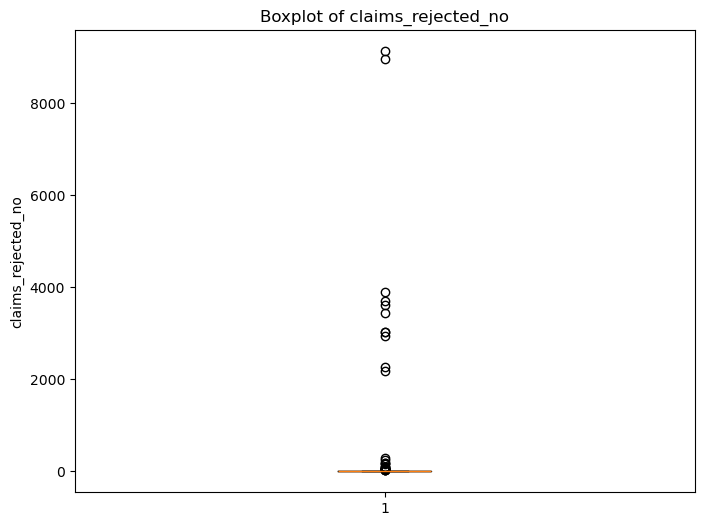

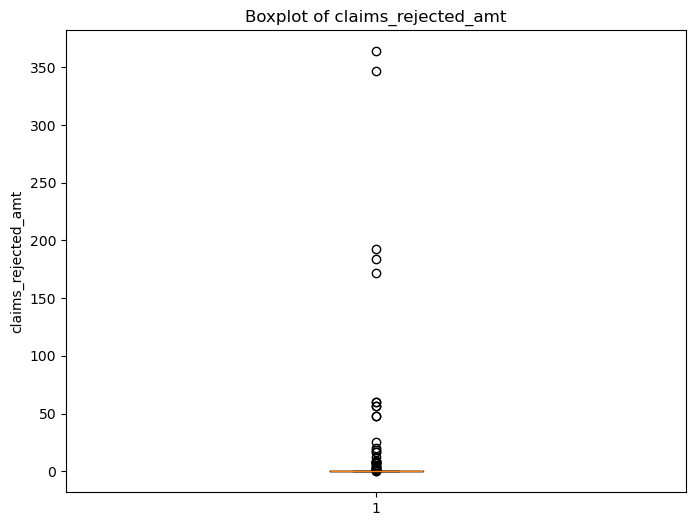

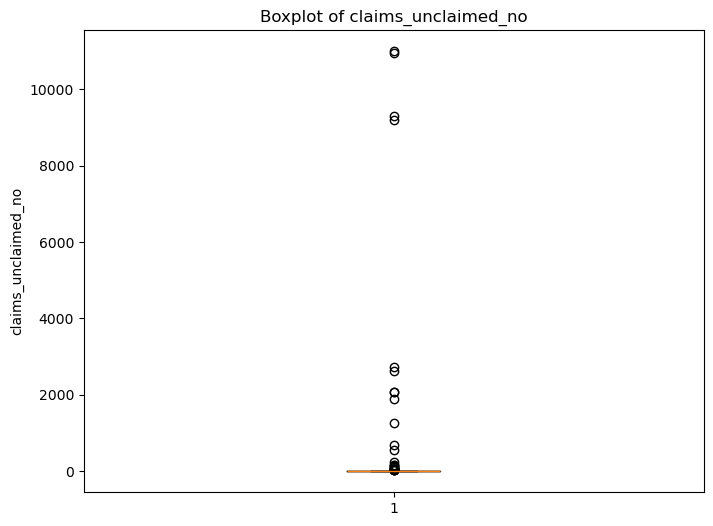

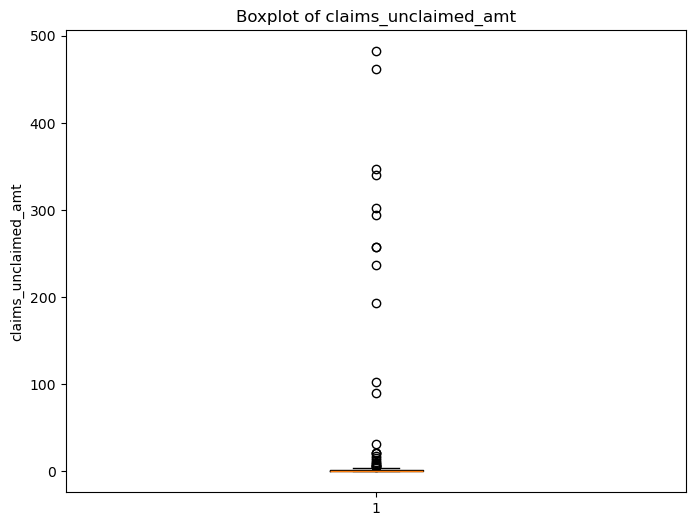

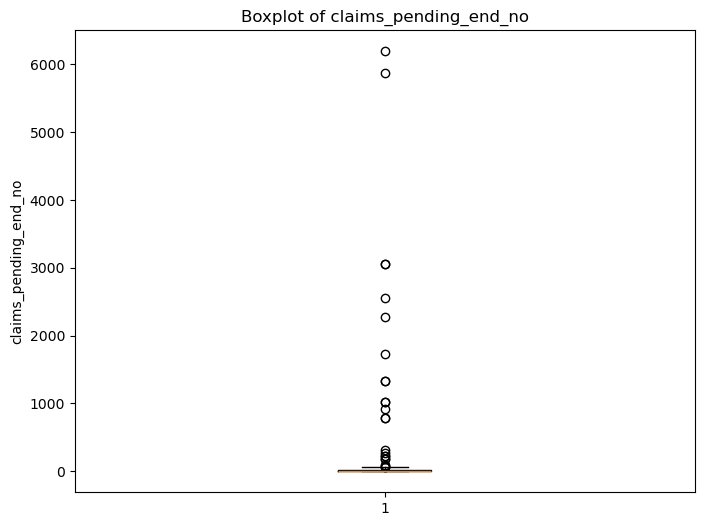

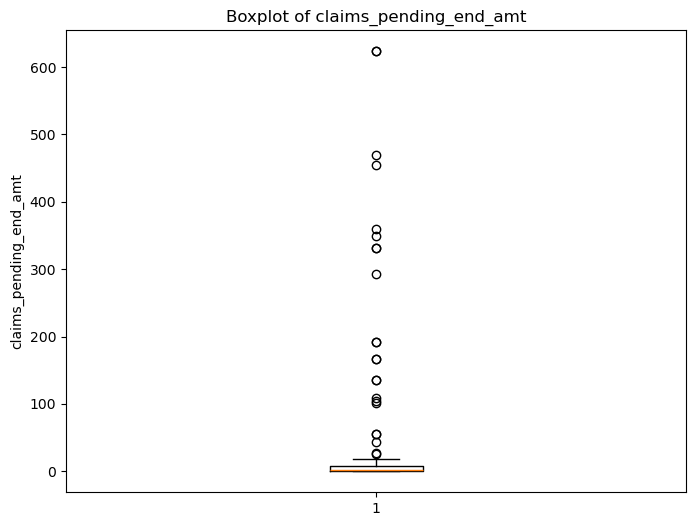

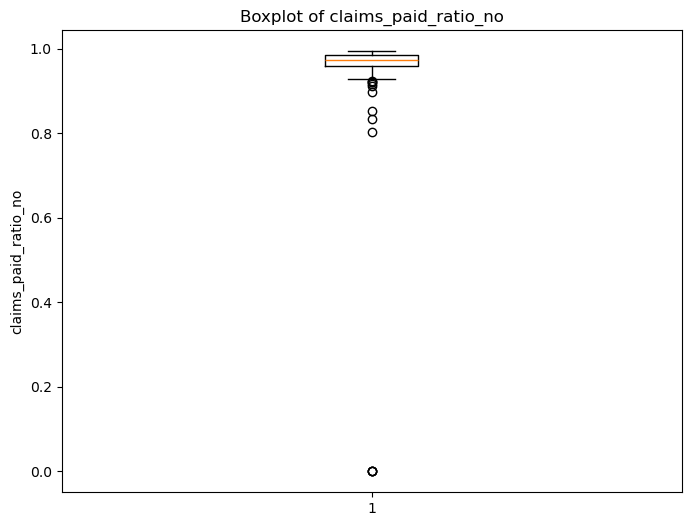

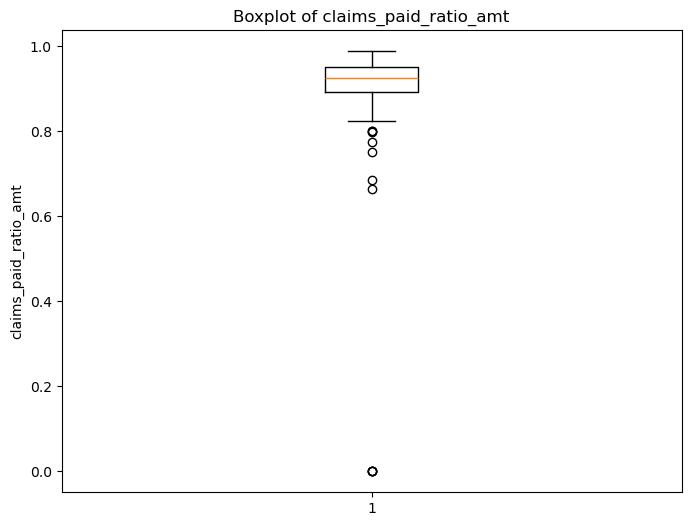

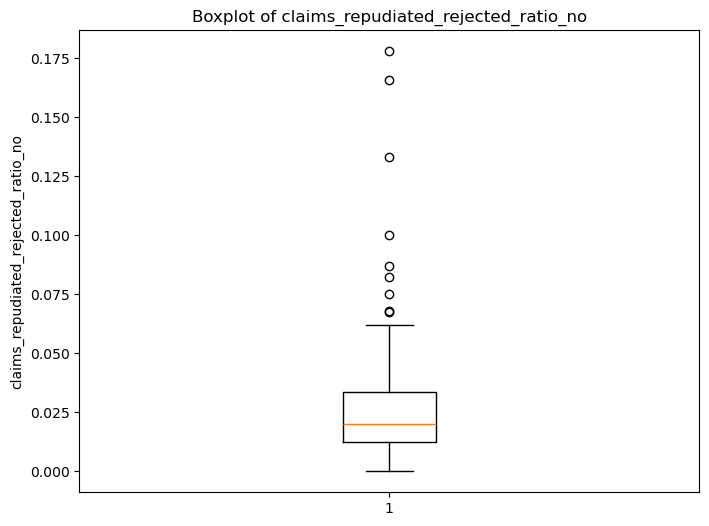

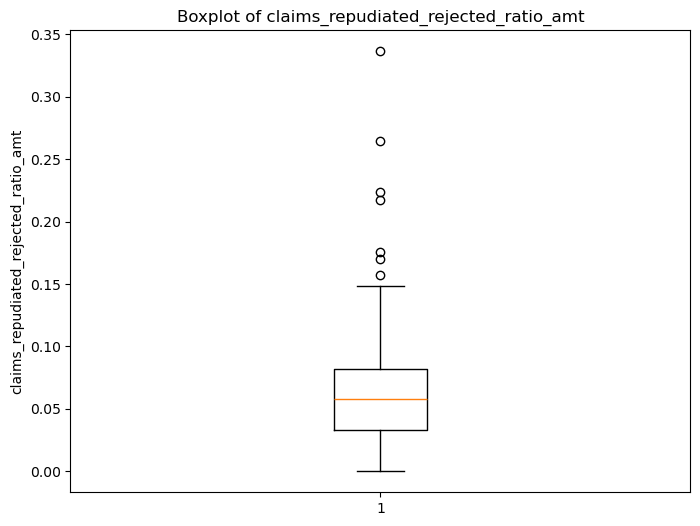

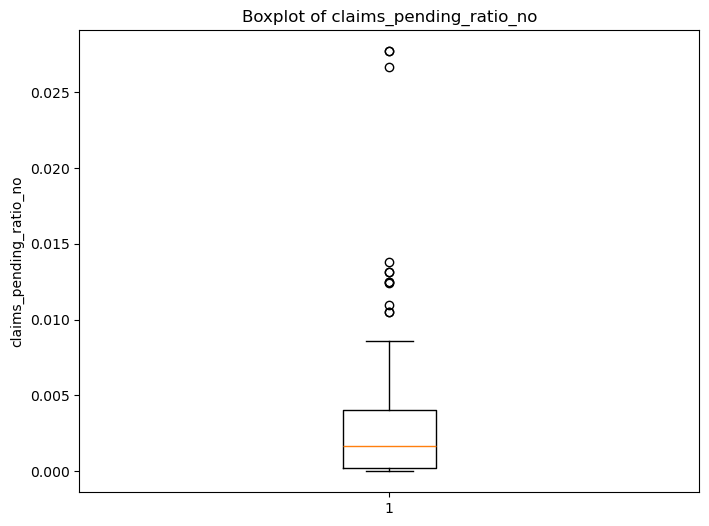

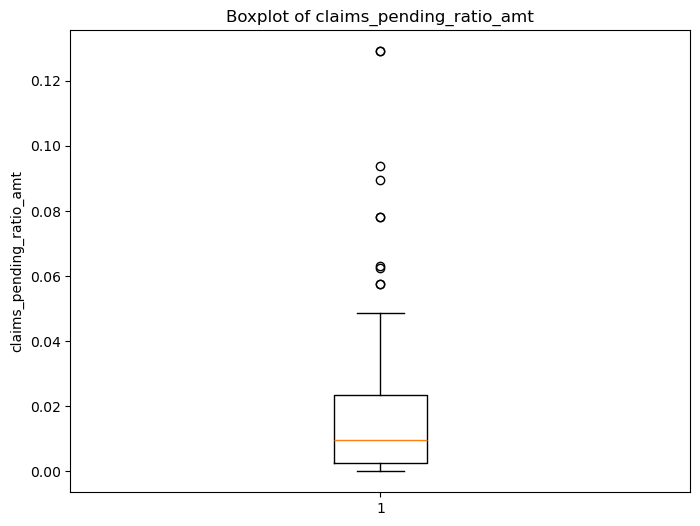

In [5]:
# Generate boxplots
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

## 6. Correlation Analysis
Compute and visualize the correlation matrix.

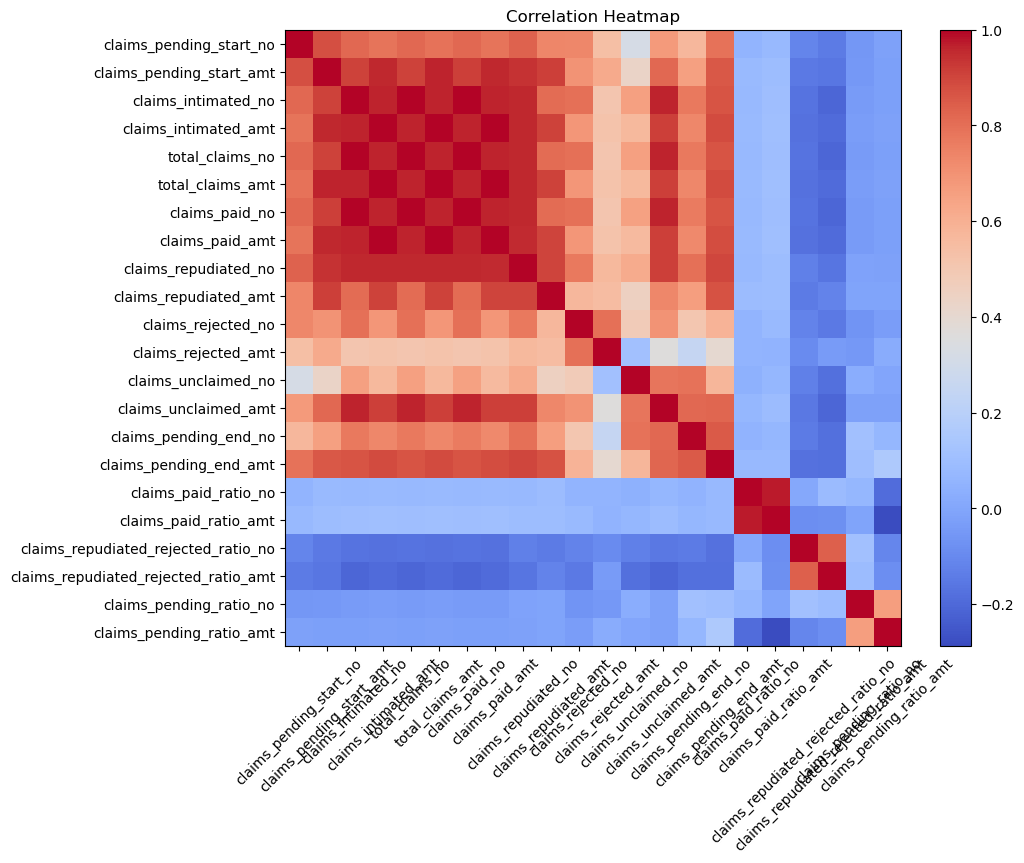

In [6]:
# Compute correlation matrix
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Correlation Heatmap')
plt.show()

## 7. Key Business Visualizations
Create specified business-relevant plots.

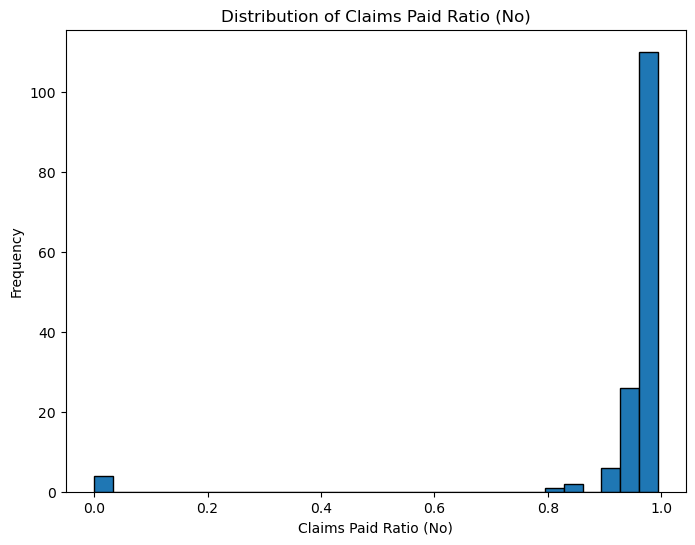

C:\Users\Nabeel-IT\AppData\Local\Temp\ipykernel_3816\3781474539.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  year_trend = df.groupby('year')['claims_paid_no'].sum()


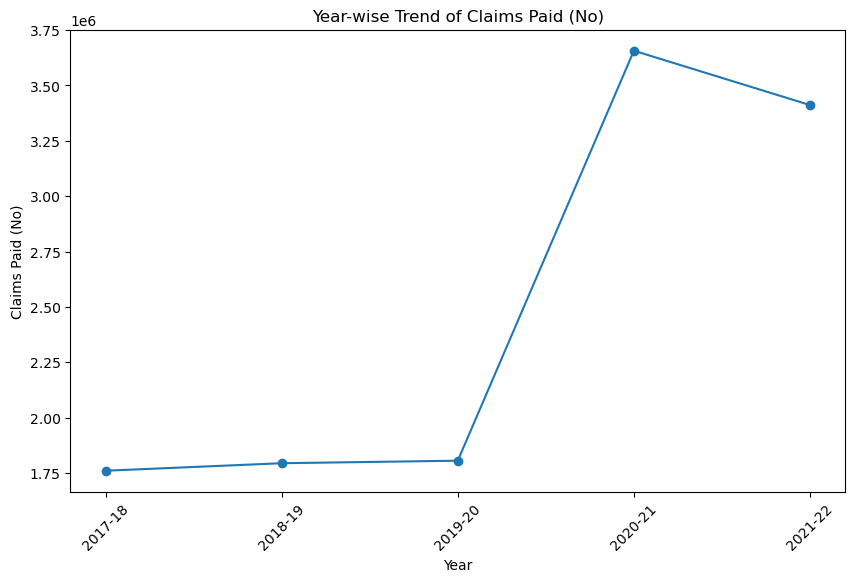

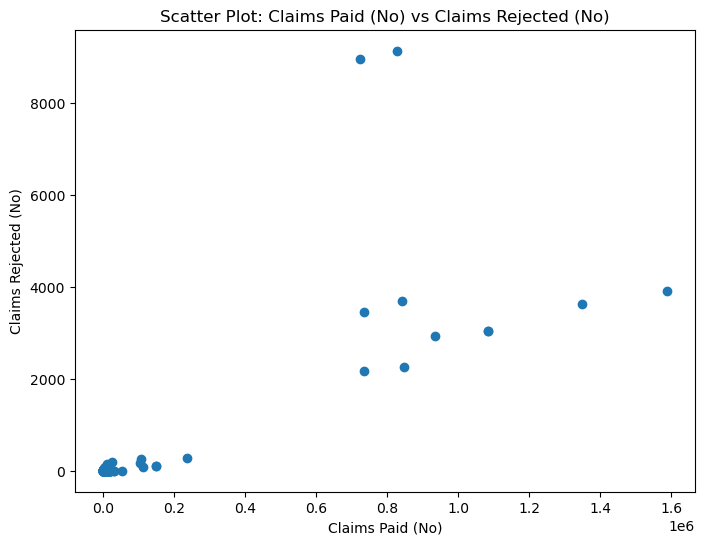

In [7]:
# a) Top 10 insurers by claims_paid_no
if 'claims_paid_no' in df.columns and 'insurer' in df.columns:
    top_insurers = df.groupby('insurer')['claims_paid_no'].sum().sort_values(ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    top_insurers.plot(kind='bar')
    plt.title('Top 10 Life Insurers by Claims Paid (No)')
    plt.xlabel('Insurer')
    plt.ylabel('Claims Paid (No)')
    plt.xticks(rotation=45)
    plt.show()

# b) Distribution of claims_paid_ratio_no
if 'claims_paid_ratio_no' in df.columns:
    plt.figure(figsize=(8, 6))
    plt.hist(df['claims_paid_ratio_no'], bins=30, edgecolor='black')
    plt.title('Distribution of Claims Paid Ratio (No)')
    plt.xlabel('Claims Paid Ratio (No)')
    plt.ylabel('Frequency')
    plt.show()

# c) Year-wise trend of claims_paid_no
if 'year' in df.columns and 'claims_paid_no' in df.columns:
    year_trend = df.groupby('year')['claims_paid_no'].sum()
    plt.figure(figsize=(10, 6))
    plt.plot(year_trend.index.astype(str), year_trend.values, marker='o')
    plt.title('Year-wise Trend of Claims Paid (No)')
    plt.xlabel('Year')
    plt.ylabel('Claims Paid (No)')
    plt.xticks(rotation=45)
    plt.show()

# d) Scatter plot: claims_paid_no vs claims_rejected_no
if 'claims_paid_no' in df.columns and 'claims_rejected_no' in df.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(df['claims_paid_no'], df['claims_rejected_no'])
    plt.title('Scatter Plot: Claims Paid (No) vs Claims Rejected (No)')
    plt.xlabel('Claims Paid (No)')
    plt.ylabel('Claims Rejected (No)')
    plt.show()

## 8. Feature Engineering
Create efficiency_score and plot top 10 insurers.

In [8]:
# Create efficiency_score
if all(col in df.columns for col in ['claims_paid_ratio_no', 'claims_pending_ratio_no', 'claims_repudiated_rejected_ratio_no']):
    df['efficiency_score'] = (df['claims_paid_ratio_no'] - 
                              df['claims_pending_ratio_no'] - 
                              df['claims_repudiated_rejected_ratio_no'])
    print("Created 'efficiency_score' column.")

    # Plot top 10 insurers by efficiency_score
    if 'insurer' in df.columns:
        top_efficiency = df.groupby('insurer')['efficiency_score'].mean().sort_values(ascending=False).head(10)
        plt.figure(figsize=(10, 6))
        top_efficiency.plot(kind='bar')
        plt.title('Top 10 Insurers by Efficiency Score')
        plt.xlabel('Insurer')
        plt.ylabel('Efficiency Score')
        plt.xticks(rotation=45)
        plt.show()

Created 'efficiency_score' column.


## 9. Skewness Analysis
Print skewness and apply log transformation on claims_intimated_no.

Skewness of numerical columns:
claims_pending_start_no                 4.802497
claims_pending_start_amt                3.950365
claims_intimated_no                     3.701959
claims_intimated_amt                    4.158935
total_claims_no                         3.699720
total_claims_amt                        4.155856
claims_paid_no                          3.718434
claims_paid_amt                         4.207083
claims_repudiated_no                    3.374192
claims_repudiated_amt                   3.478147
claims_rejected_no                      5.154240
claims_rejected_amt                     5.683405
claims_unclaimed_no                     5.457601
claims_unclaimed_amt                    3.886547
claims_pending_end_no                   5.222382
claims_pending_end_amt                  3.668680
claims_paid_ratio_no                   -5.663608
claims_paid_ratio_amt                  -4.971330
claims_repudiated_rejected_ratio_no     3.156129
claims_repudiated_rejected_ratio_amt  

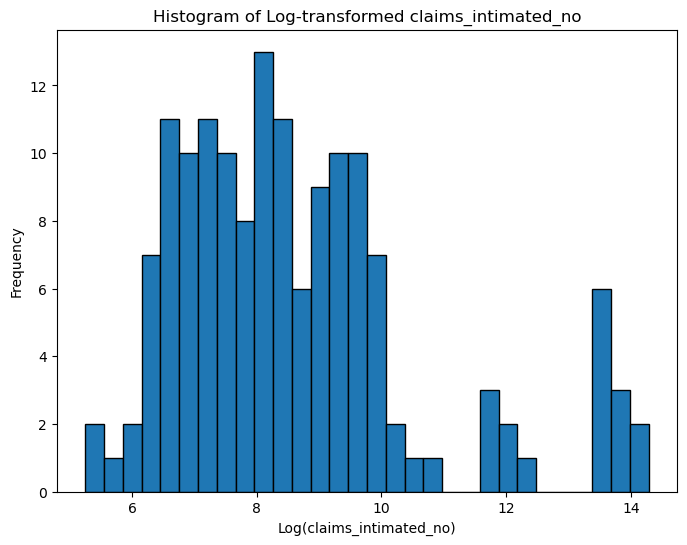

In [9]:
# Print skewness
skewness = df.select_dtypes(include=[np.number]).skew()
print("Skewness of numerical columns:")
print(skewness)

# Apply log transformation on claims_intimated_no
if 'claims_intimated_no' in df.columns:
    df['claims_intimated_no_log'] = np.log1p(df['claims_intimated_no'])
    print("Applied log transformation on 'claims_intimated_no'.")

    # Plot histogram of transformed data
    plt.figure(figsize=(8, 6))
    plt.hist(df['claims_intimated_no_log'], bins=30, edgecolor='black')
    plt.title('Histogram of Log-transformed claims_intimated_no')
    plt.xlabel('Log(claims_intimated_no)')
    plt.ylabel('Frequency')
    plt.show()

## 10. Save Output
Save the cleaned dataset.

In [10]:
# Save cleaned dataset
df.to_csv('cleaned_li_death_claims.csv', index=False)
print("Cleaned dataset saved as 'cleaned_li_death_claims.csv'")

Cleaned dataset saved as 'cleaned_li_death_claims.csv'
